# Project: Teaching an LLM to Reason

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

In [1]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime

time: 220 μs (started: 2026-04-09 17:30:58 +00:00)


In [2]:
# Verify we have enough GPU memory to run this project (at least 15360MiB)
# No changes needed in this cell

!nvidia-smi

Thu Apr  9 17:31:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   34C    P0             24W /   70W |     235MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Load the `Qwen 2.5 3B Instruct`, and set parameters for the project
# The first time unsloth is imported, it will do its magic and patch the modules
# it works with. This may 2-5 minutes.
# TODO: Fill in the missing parts marked with **********

import unsloth
from unsloth import FastLanguageModel
import torch

max_seq_length = 384  # Increase if you get errors about the sequence length

# ✅ 一定要定义
lora_rank = 16  # Small but sufficient for structured reasoning tasks like letter counting

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # We'll use quantization!
    fast_inference=True,  # This uses vllm for faster inference
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",  # Unsloth enables longer contexts
)

INFO 04-09 17:38:51 [vllm_utils.py:688] Unsloth: Patching vLLM v1 graph capture
INFO 04-09 17:38:51 [vllm_utils.py:716] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2025.9.7: Fast Qwen2 patching. Transformers: 4.55.4. vLLM: 0.10.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.31. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit with actual GPU utilization = 48.74%
Unsloth: Your GPU has CUDA compute capability 7.5 with VRAM = 14.56 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 384. Num Sequences = 192.
Unsloth: vLLM's KV Cache can use up to 4.85 GB. Also swap space = 0 GB.
WARNING 04-09 17:38:53 [compilation.py

2026-04-09 17:39:22,725	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 04-09 17:39:23 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=2048.
Unsloth: vLLM Bitsandbytes config using kwargs = {'load_in_8bit': False, 'load_in_4bit': True, 'bnb_4bit_compute_dtype': 'float16', 'bnb_4bit_quant_storage': 'uint8', 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': ['lm_head', 'multi_modal_projector', 'merger', 'modality_projection', 'model.layers.2.mlp', 'model.layers.3.mlp', 'model.layers.30.mlp'], 'llm_int8_threshold': 6.0}
INFO 04-09 17:39:23 [llm_engine.py:222] Initializing a V0 LLM engine (v0.10.1) with config: model='unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit', speculative_config=None, tokenizer='unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_le

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.85s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.85s/it]

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:16<00:00, 16.87s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:16<00:00, 16.88s/it]


INFO 04-09 17:40:13 [punica_selector.py:19] Using PunicaWrapperGPU.


...

Capturing CUDA graph shapes: 100%|██████████| 27/27 [00:25<00:00,  1.05it/s]

INFO 04-09 17:40:50 [model_runner.py:1535] Graph capturing finished in 26 secs, took 0.56 GiB
INFO 04-09 17:40:50 [vllm_utils.py:728] Unsloth: Patched vLLM v0 graph capture finished in 26 secs.


INFO 04-09 17:40:51 [llm_engine.py:417] init engine (profile, create kv cache, warmup model) took 36.38 seconds
INFO 04-09 17:40:51 [llm.py:298] Supported_tasks: ['generate']
Unsloth: Just some info: will skip parsing ['norm1', 'layer_norm1', 'k_norm', 'layer_norm2', 'q_norm', 'post_feedforward_layernorm', 'post_attention_layernorm', 'norm2', 'post_layernorm', 'pre_feedforward_layernorm', 'input_layernorm']
Unsloth: Just some info: will skip parsing ['norm1', 'layer_norm1', 'k_norm', 'layer_norm2', 'q_norm', 'post_feedforward_layernorm', 'cross_attn_post_attention_layernorm', 'post_attention_layernorm', 'norm2', 'cross_attn_input_layernorm', 'post_layernorm', 'pre_feedforward_layernorm', 'input_layernorm']


Unsloth 2025.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


time: 2min 12s (started: 2026-04-09 17:38:50 +00:00)


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [5]:
# First, let's see what happens when we have a blank system prompt
# No changes needed in this cell
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

# Set the LLM sampling parameters
sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

# Generate the text completion
output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Processed prompts: 100%|██████████| 1/1 [00:05<00:00,  5.68s/it, est. speed input: 5.10 toks/s, output: 2.64 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".
time: 5.7 s (started: 2026-04-09 17:45:26 +00:00)


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [7]:
# Let's work on a new system prompt that will help the model break this problem
# down into steps, for example, using "letter-by-letter" spelling.
# TODO: Fill in the missing parts marked with **********

# Use a CoT prompt with at least one example
SYSTEM_PROMPT = """
You are an assistant that carefully counts letters in words.

When answering questions about how many times a letter appears in a word, follow this process:
1. Spell the word letter by letter in order.
2. Keep a running count of how many times the target letter has appeared.
3. After checking all letters, clearly state the final count.

Always show your reasoning before giving the final answer.

Example:

Question: How many of the letter "o" are there in the word "room"?

Reasoning:
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o so far
3. o - 2 o's so far
4. m - 2 o's so far

Final Answer:
2
"""

time: 636 μs (started: 2026-04-09 17:47:55 +00:00)


Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

Yes, the model produced the correct answer and followed the instructions in this example, but the behavior is not guaranteed to be reliable across variations. Therefore, we proceed with GRPO to improve consistency.

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [8]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

time: 5.44 ms (started: 2026-04-09 17:49:42 +00:00)


In [9]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

Generating train split: 401 examples [00:00, 8704.58 examples/s]


{'words': 'idea', 'letters': 'a', 'counts': 1}

time: 368 ms (started: 2026-04-09 17:50:26 +00:00)


In [10]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

Map: 100%|██████████| 401/401 [00:00<00:00, 4525.55 examples/s]


{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

time: 103 ms (started: 2026-04-09 17:50:56 +00:00)


In [11]:
# Let's see how well the model runs out-of-the-box
# No changes needed in this cell

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

from vllm import SamplingParams

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=1024,
)
output = (
    model.fast_generate(
        [text],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print(output)

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.72s/it, est. speed input: 61.06 toks/s, output: 37.80 toks/s]

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>
time: 1.73 s (started: 2026-04-09 17:51:49 +00:00)


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [12]:
# Numbering reward function
# This reward encourages correct, in-order numbering of letter-by-letter spelling

import re


def extract_letter_numbering(response: str):
    """Extract the numbers at the beginning of each letter-by-letter line.

    Example input lines:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far

    Returns:
    [1, 2, 3]
    """
    # Match lines like: "\n1. g"
    pattern = r"\n(\d+)\. [a-z]"
    matches = re.findall(pattern, response)
    if matches:
        return [int(m) for m in matches]
    return []


# Sanity check for the extractor
assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Reward correct in-order numbering of letter-by-letter spelling.

    - +1 for correct in-order numbering (1, 2, 3, ...)
    - -1 for out-of-order numbering
    - -1 for continuing beyond the length of the word

    The final reward is normalized by the word length.
    """
    responses = [completion[0]["content"] for completion in completions]

    rewards = []
    for response, word in zip(responses, words):
        reward = 0.0

        numbers = extract_letter_numbering(response)
        for ix, spell_number in enumerate(numbers):
            expected_number = ix + 1

            # Correct in-order numbering
            if spell_number == expected_number:
                reward += 1.0
            else:
                reward -= 1.0

            # Penalize extra lines beyond the word length
            if expected_number > len(word):
                reward -= 1.0

        rewards.append(reward / len(word))

    return rewards


# Test the reward function
res = numbering_reward_func(
    completions=[
        [
            {  # Worse response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
1. l - 2 so far
1. l - 2 so far
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {  # Better response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-0.5, 0.5]
time: 2.5 ms (started: 2026-04-09 17:59:31 +00:00)


### Spelling reward function

In [13]:
# Spelling reward function
# Reward correct spelling of the word

import re
from collections import Counter


def extract_spelling(response):
    """Extract the spelling from the response.

    Example lines:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. l - 2 so far
    5. l - 2 so far

    Returns:
    "goall"
    """
    pattern = r"\n\d+\. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join(matches)
    return ""


# Sanity check
assert extract_spelling(
    """Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
) == "goall"


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """Reward correct spelling of the target word.

    Components:
    - +1.0 for exactly correct spelling
    - -0.5 for each letter of length difference
    - -0.5 for each extra letter not in the target word
    - -0.5 for each missing letter from the target word
    """
    responses = [completion[0]["content"] for completion in completions]

    rewards = []

    for word, response in zip(words, responses):
        reward = 0.0

        spelled = extract_spelling(response)

        # 1. Exact spelling reward
        if spelled == word:
            reward += 1.0

        # 2. Length difference penalty
        reward -= 0.5 * abs(len(spelled) - len(word))

        # 3 & 4. Character-level difference penalties
        spelled_counter = Counter(spelled)
        word_counter = Counter(word)

        # Extra letters (in response but not needed)
        extra_letters = spelled_counter - word_counter
        reward -= 0.5 * sum(extra_letters.values())

        # Missing letters (in word but not in response)
        missing_letters = word_counter - spelled_counter
        reward -= 0.5 * sum(missing_letters.values())

        rewards.append(reward)

    return rewards


# Test the reward function
res = spelling_reward_func(
    completions=[
        [  # Worse response (extra 'l')
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [  # Better response (correct spelling)
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-1.0, 1.0]
time: 2.79 ms (started: 2026-04-09 18:01:05 +00:00)


### Counting reward function

In [14]:
# Counting reward function
# Reward the model for properly counting occurrences of a letter in a word

import re


def get_resp_letters_and_counts(response):
    """Extract the letters and counts from the response.

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far

    Returns:
    [('g', '1'), ('o', '1'), ('a', '2'), ('a', '2'), ('l', '2')]
    """
    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)

    if not matches:
        return []

    return [
        (matched_letter.lower(), matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]


# Sanity check
assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]

    rewards = []

    # Iterate over each (target letter, response) pair
    for letter, response in zip(letters, responses):
        reward = 0.0
        letter = letter.lower()

        letters_and_counts = get_resp_letters_and_counts(response)

        # If nothing could be parsed, strong negative reward
        if not letters_and_counts:
            rewards.append(-1.0)
            continue

        actual_count = 0

        for resp_letter, resp_count_str in letters_and_counts:
            resp_count = int(resp_count_str)

            # Update the true running count
            if resp_letter == letter:
                actual_count += 1

            # Reward correct running count, penalize incorrect
            if resp_count == actual_count:
                reward += 1.0
            else:
                reward -= 1.0

        # Normalize by the number of parsed steps
        rewards.append(reward / len(letters_and_counts))

    return rewards


# Test the reward function
res = counting_reward_func(
    completions=[
        [  # Worse response (inconsistent running counts)
            {
                "content": """<reasoning>
Here is a letter by letter spelling:

1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far

</reasoning>
<answer>
This is my answer.
</answer>"""
            }
        ],
        [  # Better response (consistent running counts)
            {
                "content": """<reasoning>
Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far

</reasoning>
<answer>
This is my answer.
</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-0.6, 1.0]
time: 2.98 ms (started: 2026-04-09 18:04:04 +00:00)


### Formatting reward functions



In [15]:
# Formatting reward function
# Reward the model for providing the response in a specific format

import re


def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""
    pattern = r"&lt;answer&gt;(.*?)&lt;/answer&gt;"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""


# Sanity check
assert (
    extract_xml_answer("""
&lt;reasoning&gt;
This is my reasoning.
&lt;/reasoning&gt;
&lt;answer&gt;SUPERCALIFRAGILISTICEXPIALIDOCIOUS&lt;/answer&gt;
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has a specific format.

    Rewards:
    - +0.5 if the response contains both <reasoning>...</reasoning> and <answer>...</answer>
    - +0.5 if the extracted answer is an integer
    """
    pattern = r"\s*&lt;reasoning&gt;.*?&lt;/reasoning&gt;\s*&lt;answer&gt;.*?&lt;/answer&gt;"

    rewards = []

    for completion in completions:
        reward = 0.0

        # Extract the response content
        response = completion[0]["content"]

        # Check if the response matches the required format
        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)

        # Reward correct overall format
        if match:
            reward += 0.5

            # Extract the answer text
            extracted_answer = extract_xml_answer(response)

            # Reward if the answer is an integer
            if extracted_answer.isdigit():
                reward += 0.5

        rewards.append(reward)

    return rewards


# Test the reward function
res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "&lt;reasoning&gt;\nThis is my reasoning.\n&lt;/reasoning&gt;\n&lt;answer&gt;\n3\n&lt;/answer&gt;"
            }
        ],
    ]
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[0.0, 1.0]
time: 2.38 ms (started: 2026-04-09 18:05:14 +00:00)


### Task correctness reward function

In [19]:
# Task correctness reward function
# Reward the model for providing the correct final answer

import re


def extract_xml_answer(text: str) -> str:
    """Extract the string between <answer>...</answer> or &lt;answer&gt;...&lt;/answer&gt;."""
    patterns = [
        r"<answer>(.*?)</answer>",
        r"&lt;answer&gt;(.*?)&lt;/answer&gt;",
    ]

    for pattern in patterns:
        match = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
        if match:
            return match.group(1).strip()

    return ""


def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is exactly correct."""
    responses = [completion[0]["content"] for completion in completions]
    extracted_responses = [extract_xml_answer(r) for r in responses]

    # Debug print (safe to keep during training)
    print(
        f"""
--------------------
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
"""
    )

    # +1.0 for correct answer, else 0.0
    rewards = [
        1.0 if str(r).strip() == str(a) else 0.0
        for r, a in zip(extracted_responses, counts)
    ]

    return rewards


# ✅ Test: must pass
res = correct_answer_reward_func(
    prompts=[
        [{"content": "How many..."}],
        [{"content": "How many..."}],
    ],
    completions=[
        [
            {
                "content": "&lt;reasoning&gt;.../reasoning&gt;\n&lt;answer&gt;\n3\n&lt;/answer&gt;"
            }
        ],
        [
            {
                "content": "&lt;reasoning&gt;.../reasoning&gt;\n&lt;answer&gt;\n3\n&lt;/answer&gt;"
            }
        ],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


--------------------
Question: How many...
Answer: 0
Response: &lt;reasoning&gt;.../reasoning&gt;
&lt;answer&gt;
3
&lt;/answer&gt;
Extracted: 3
Correct: False!

[0.0, 1.0]
time: 2.11 ms (started: 2026-04-09 18:11:41 +00:00)


### List the reward functions

In [20]:
# List out the reward functions we will use
# No changes needed in this cell

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

time: 570 μs (started: 2026-04-09 18:12:14 +00:00)


## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [21]:
COMMON_GRPO_TRAINING_PARAMS = dict(
    # Learning rate and GRPO beta
    learning_rate=2e-4,   # Safe and commonly used for LoRA + GRPO
    beta=0.04,            # Controls KL penalty strength (stable choice)

    # Batch & generation settings (T4-friendly)
    per_device_train_batch_size=8,   # <=16 is recommended on T4
    num_generations=4,               # Number of completions per prompt
    gradient_accumulation_steps=2,   # Effective batch = 8 * 2 = 16 prompts

    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",

    logging_steps=1,

    max_prompt_length=256,
    max_completion_length=200,

    num_train_epochs=1,   # 1 epoch is enough for this toy task
    save_steps=250,
    max_grad_norm=0.1,

    report_to="none",
    output_dir="outputs",

    use_vllm=True,  # vLLM speeds up rollout generation
)

time: 769 μs (started: 2026-04-09 18:13:27 +00:00)


### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [22]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Note, you won't see much change in the average.
# reward values
# No changes are needed here

from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far (no additional 'l's, so the count remains 1)
3. i - 0 so far (no additional 'i's, so the count remains 1)
4. s - 0 so far (no additional 's's, so the count remains 1)
5. t - 0 so far (no additional 't's, so the count remains 1)
6. e - 0 so far (no additional 'e's, so the count remains 1)
7. n - 0 so far (no additional 'n's, so the count remains 1)
8. n - 1 so far (one additional 'n', total count is 2)
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,1.262053,1.717800,88.125000,39.000000,191.000000,0.000000,88.125000,39.000000,191.000000,0.000000,0.890625,0.302335,-0.250000,1.341641,-0.003571,0.700661,0.000000,0.000000,0.625000,0.500000
2,0.000000,0.915972,0.873562,78.562500,57.000000,111.000000,0.000000,78.562500,57.000000,111.000000,0.000014,0.937500,0.111803,-0.687500,1.662077,0.040972,0.599296,0.000000,0.000000,0.625000,0.500000
3,0.005600,2.517857,0.667210,91.375000,66.000000,113.000000,0.000000,91.375000,66.000000,113.000000,0.070006,0.982143,0.048795,0.125000,0.957427,0.535714,0.513756,0.000000,0.000000,0.875000,0.341565
4,0.006700,1.158333,0.394651,68.125000,62.000000,71.000000,0.000000,68.125000,62.000000,71.000000,0.083673,0.937500,0.083333,-0.562500,1.152895,0.033333,0.401479,0.000000,0.000000,0.750000,0.447214
5,0.008100,1.136012,0.874158,65.937500,53.000000,88.000000,0.000000,65.937500,53.000000,88.000000,0.101317,0.871429,0.255551,-0.187500,1.376893,-0.047917,0.422509,0.000000,0.000000,0.500000,0.516398



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word sapphire
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 3 so far
6. h - 3 so far
7. a - 4 so far
8. p - 4 so far
9. y - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!


--------------------
Question: How many of the letter "q" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of "q"s in the word "absolve":
1. a - 0 so far
2. b - 0 so far
3. s - 0 so far
4. l - 0 so far
5. o - 0 so far
6. v - 0 so far
7. e - 0 so far
Thus, there are 0 "q"s in the word "absolve".
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!


--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
1. m - 0 so far
2. i - 0 so far
3. r - 0 so far
4. a - 1 so far
5. g - 1 so far
</reasoning>
<answer>
2

Matplotlib is building the font cache; this may take a moment.


available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


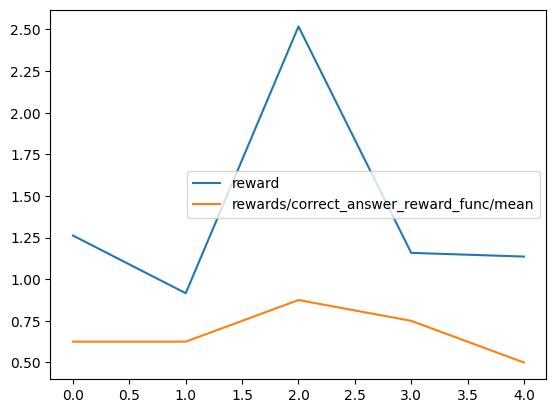

time: 7.78 s (started: 2026-04-09 18:16:56 +00:00)


In [23]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [24]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.
# TODO: Fill out the areas where you find **********

# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # ~1 hour on a single Tesla T4 based on quick-train timing
    max_steps=300,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)

trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 3 | Total steps = 300
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
1. g - 1 so far
2. l - 0 so far
3. i - 0 so far
4. s - 0 so far
5. n - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!



Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.008800,1.715030,0.656885,62.500000,53.000000,85.000000,0.000000,62.500000,53.000000,85.000000,0.110174,0.881696,0.210570,-0.062500,1.340087,0.020833,0.424591,0.000000,0.000000,0.875000,0.341565
2,0.009100,1.267014,0.504861,66.062500,53.000000,109.000000,0.000000,66.062500,53.000000,109.000000,0.114239,1.000000,0.000000,0.062500,1.569236,-0.107986,0.505692,0.000000,0.000000,0.312500,0.478714
3,0.006500,1.120536,1.280094,63.937500,26.000000,80.000000,0.000000,63.937500,26.000000,80.000000,0.081203,0.837798,0.243931,-0.875000,2.187083,0.345238,0.755329,0.000000,0.000000,0.812500,0.403113
4,0.005600,1.529167,0.528306,70.937500,53.000000,87.000000,0.000000,70.937500,53.000000,87.000000,0.069472,0.937500,0.119799,-0.125000,1.310216,0.029167,0.542542,0.000000,0.000000,0.687500,0.478714
5,0.005200,1.093601,0.841012,71.250000,53.000000,98.000000,0.000000,71.250000,53.000000,98.000000,0.064754,0.915923,0.138660,-0.187500,1.276388,-0.072321,0.417226,0.000000,0.000000,0.437500,0.512348
6,0.007900,2.258184,0.772815,68.312500,44.000000,97.000000,0.000000,68.312500,44.000000,97.000000,0.098158,0.984375,0.062500,0.125000,0.885061,0.398810,0.554818,0.000000,0.000000,0.750000,0.447214
7,0.005700,0.283333,0.753987,55.250000,35.000000,71.000000,0.000000,55.250000,35.000000,71.000000,0.071571,0.781250,0.199436,-1.000000,1.414214,-0.060417,0.509788,0.000000,0.000000,0.562500,0.512348
8,0.004300,1.608929,0.573382,77.562500,62.000000,103.000000,0.000000,77.562500,62.000000,103.000000,0.054014,0.964286,0.063888,-0.750000,0.856349,0.457143,0.532073,0.000000,0.000000,0.937500,0.250000
9,0.008800,1.371131,1.000835,77.312500,53.000000,120.000000,0.000000,77.312500,53.000000,120.000000,0.110210,0.971726,0.060994,-0.562500,1.209339,0.274405,0.571357,0.000000,0.000000,0.687500,0.478714
10,0.005600,2.860714,0.499073,64.125000,53.000000,80.000000,0.000000,64.125000,53.000000,80.000000,0.070392,1.000000,0.000000,0.750000,0.683130,0.235714,0.399387,0.000000,0.000000,0.875000,0.341565



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. r - 1 so far
6. a - 3 so far
7. y - 1 so far
8. e - 3 so far
</reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!


--------------------
Question: How many of the letter "q" are there in the word "absolve"
Answer: 0
Response: <reasoning>
1. a - 1 so far
2. b - 1 so far
3. s - 1 so far
4. q - 0 so far
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!


--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
1. m - 0 so far
2. i - 0 so far
3. r - 0 so far
4. a - 1 so far
5. g - 1 so far
6. e - 1 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!


--------------------
Question: How many of the letter "r" are there in the word "crave"
Answer: 1
Response: <reasoning>
1. c - 1 so far
2. r - 1 so far

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


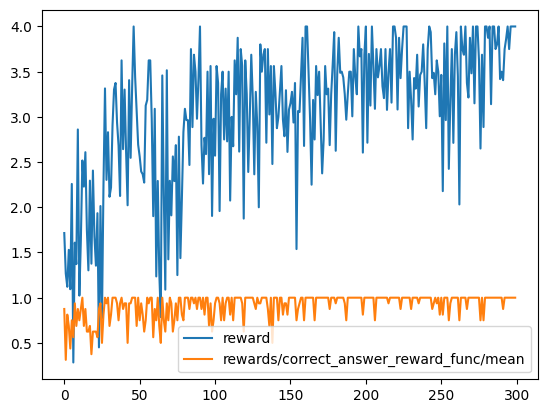

time: 189 ms (started: 2026-04-09 19:19:06 +00:00)


In [25]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## View the results
Now let's try the model we just trained!

In [26]:
# Save the LoRA adapters
# No changes needed in this cell

# Save the LoRA model
model.save_lora("grpo_saved_lora")

time: 803 ms (started: 2026-04-09 19:19:11 +00:00)


In [27]:
# Create a function to run both the original model and the updated model
# No changes needed in this cell


def compare_old_and_new_model(messages):
    from vllm import SamplingParams

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    sampling_params = SamplingParams(
        temperature=0.8,
        top_p=0.95,
        max_tokens=1024,
    )
    old = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
        )[0]
        .outputs[0]
        .text
    )

    new = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
            lora_request=model.load_lora("grpo_saved_lora"),
        )[0]
        .outputs[0]
        .text
    )

    print("===OLD===\n")
    print(old)

    print("\n\n===NEW===\n")
    print(new)


time: 1.1 ms (started: 2026-04-09 19:19:13 +00:00)


### Compare the old and new models on the letter-counting task

In [28]:
# Let's try spelling the first word from the dataset
# TODO: Fill out the areas where you find **********

# Load the first item from the dataset (index 0) and compare the old and new models

sample = ds[0]["prompt"]
compare_old_and_new_model(sample)

Processed prompts: 100%|██████████| 1/1 [00:03<00:00,  3.15s/it, est. speed input: 33.38 toks/s, output: 20.66 toks/s]

===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


===NEW===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>
time: 4.89 s (started: 2026-04-09 19:19:17 +00:00)


Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [29]:
# Let's see if the model still remembers some of the facts from its original training
# TODO: Fill out the areas where you find **********

# Ask both the old and new models a question the model is likely to know,
# e.g. a well-known capital city

messages = [
    {
        "role": "system",
        "content": "You are a helpful assistant."
    },
    {
        "role": "user",
        "content": "What is the capital of France?"
    },
]

compare_old_and_new_model(messages)

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.08it/s, est. speed input: 54.28 toks/s, output: 16.70 toks/s]

===OLD===

The capital of France is Paris.


===NEW===

The capital of France is Paris.
time: 866 ms (started: 2026-04-09 19:19:25 +00:00)


Great job! Congrats on completing the project! 🎉🤗